# Results plots

In [23]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import samples
import plot_basics
import finn.io as fio

importlib.reload(samples)
importlib.reload(plot_basics)
importlib.reload(fio)

from samples import Samples

Setup data stuff

In [ ]:
CORE_DATA_PLOT_KWARGS = dict(
    alpha=1.0,
    s=4.0,
    color="r",
    zorder=1000,
)


def plot_core_data(axs, **kwargs):
    new_kwargs = CORE_DATA_PLOT_KWARGS.copy()
    for k in kwargs.keys():
        if k in new_kwargs:
            del new_kwargs[k]

    axs[0].scatter(*fio.load_exp_data_numpy("Core 1"), **new_kwargs, **kwargs)
    axs[1].scatter(*fio.load_exp_data_numpy("Core 2"), **new_kwargs, **kwargs)
    axs[2].scatter(*fio.load_exp_data_numpy("Core 2B"), **new_kwargs, **kwargs)

Setup directories

In [25]:
input_dir = Path("../in")
output_dir = Path("../out")
results_dir = output_dir / "extended_final_results"
image_output_dir = results_dir / "images"

image_output_dir.mkdir(exist_ok=True, parents=True)

Load data

In [ ]:
core2_df = fio.load_exp_data(f"Core 2", csv=True)
core2b_df = fio.load_exp_data(f"Core 2B", csv=True)
core1_df = fio.load_exp_data(f"Core 1", csv=True)

Load relevant results

In [27]:
datasets = {
    "ddb": Samples.from_dir2(results_dir / "ddb"),
    "mcmc": Samples.from_dir(input_dir / "mcmc"),
}
datasets_list = list(datasets.values())

datasets["ddb"].core1 = datasets["ddb"].core1.T
datasets["ddb"].core2 = datasets["ddb"].core2.T
datasets["ddb"].core2b = datasets["ddb"].core2b.T
datasets["ddb"].quantiles = datasets["ddb"].quantiles.T
datasets["ddb"].mixed_quantiles = datasets["ddb"].mixed_quantiles.T
datasets["ddb"].ret_x = datasets["ddb"].ret_x.T
datasets["ddb"].ret_y = datasets["ddb"].ret_y.T

DDB samples

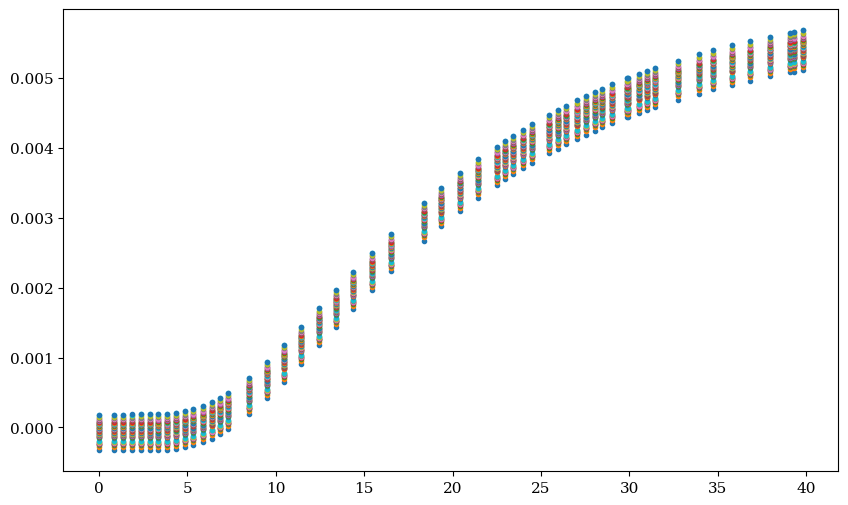

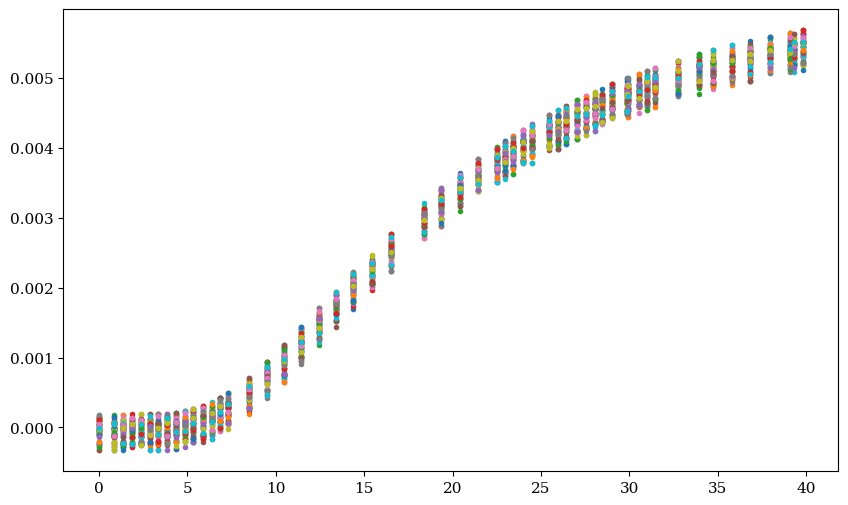

In [ ]:
plt.figure(figsize=[10, 6])
plt.plot(core2_df["time"], datasets["ddb"].quantiles.T, '.')

plt.figure(figsize=[10, 6])
plt.plot(core2_df["time"], datasets["ddb"].mixed_quantiles.T, '.')

/var/folders/3v/jk4_t2254jjf11w2hj0bw9580000gn/T/ipykernel_65750/1232753237.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


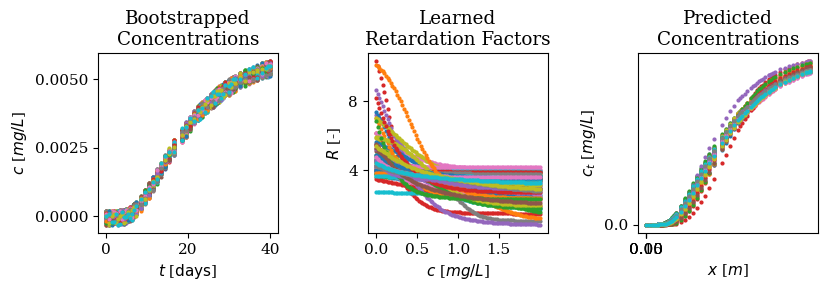

In [29]:
fig, axs = plot_basics.get_axes_for_ddb_samples()

datasets["ddb"].plot_samples(axs=axs)

plt.tight_layout()
plt.show()

/var/folders/3v/jk4_t2254jjf11w2hj0bw9580000gn/T/ipykernel_65750/3905150907.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/stefaniascheurer/Documents/Uni/Promotion/Repos/uq-finn/src/plot_basics.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


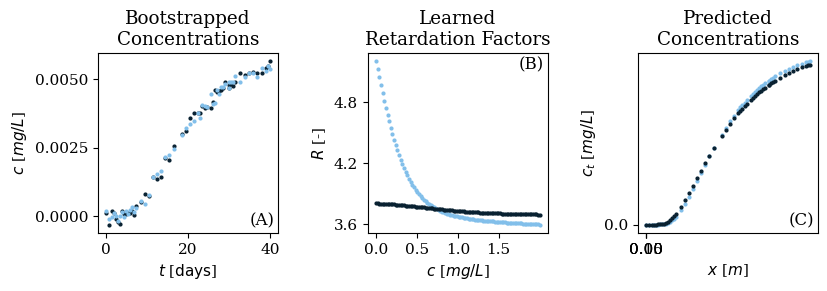

In [ ]:
fig, axs = plot_basics.get_axes_for_ddb_samples()


axs[0].text(0.98, 0.02, "(A)", transform=axs[0].transAxes, fontsize=12, va="bottom", ha="right")
axs[1].text(0.98, 0.98, "(B)", transform=axs[1].transAxes, fontsize=12, va="top", ha="right")
axs[2].text(0.98, 0.02, "(C)", transform=axs[2].transAxes, fontsize=12, va="bottom", ha="right")

# datasets["ddb"].plot_samples(axs=axs, samples=[21,22])
# datasets["ddb"].plot_samples(axs=axs, samples=[15,22])
datasets["ddb"].plot_samples(axs=axs, samples=[15, 17])

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "ddb_examples")
plt.show()

DDB results

45 70


/Users/stefaniascheurer/Documents/Uni/Promotion/Repos/uq-finn/src/plot_basics.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


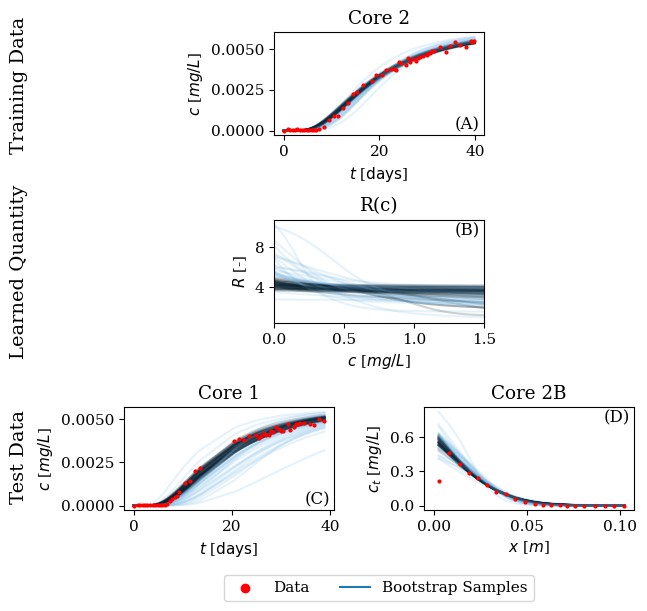

In [ ]:
fig, axs = plot_basics.get_axes_for_results()

datasets["ddb"].plot(axs=axs, double_colors=True)
plot_core_data(axs)

axs[0].text(0.98, 0.02, "(C)", transform=axs[0].transAxes, fontsize=12, va="bottom", ha="right")
axs[1].text(0.98, 0.02, "(A)", transform=axs[1].transAxes, fontsize=12, va="bottom", ha="right")
axs[2].text(0.98, 0.98, "(D)", transform=axs[2].transAxes, fontsize=12, va="top", ha="right")
axs[3].text(0.98, 0.98, "(B)", transform=axs[3].transAxes, fontsize=12, va="top", ha="right")

fig.text(-0.1, 0.83, "Training Data", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.1, 0.50, "Learned Quantity", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.1, 0.17, "Test Data", rotation=90, va="center", ha="center", fontsize=14)

fig.legend(
    [
        plt.scatter([], [], marker="o", color="r"),
        plt.plot([], [], "C0", "-")[0],
    ],
    ["Data", "Bootstrap Samples"],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.1),
)

# plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "ddb")
plt.show()

Number of bootstrap samples

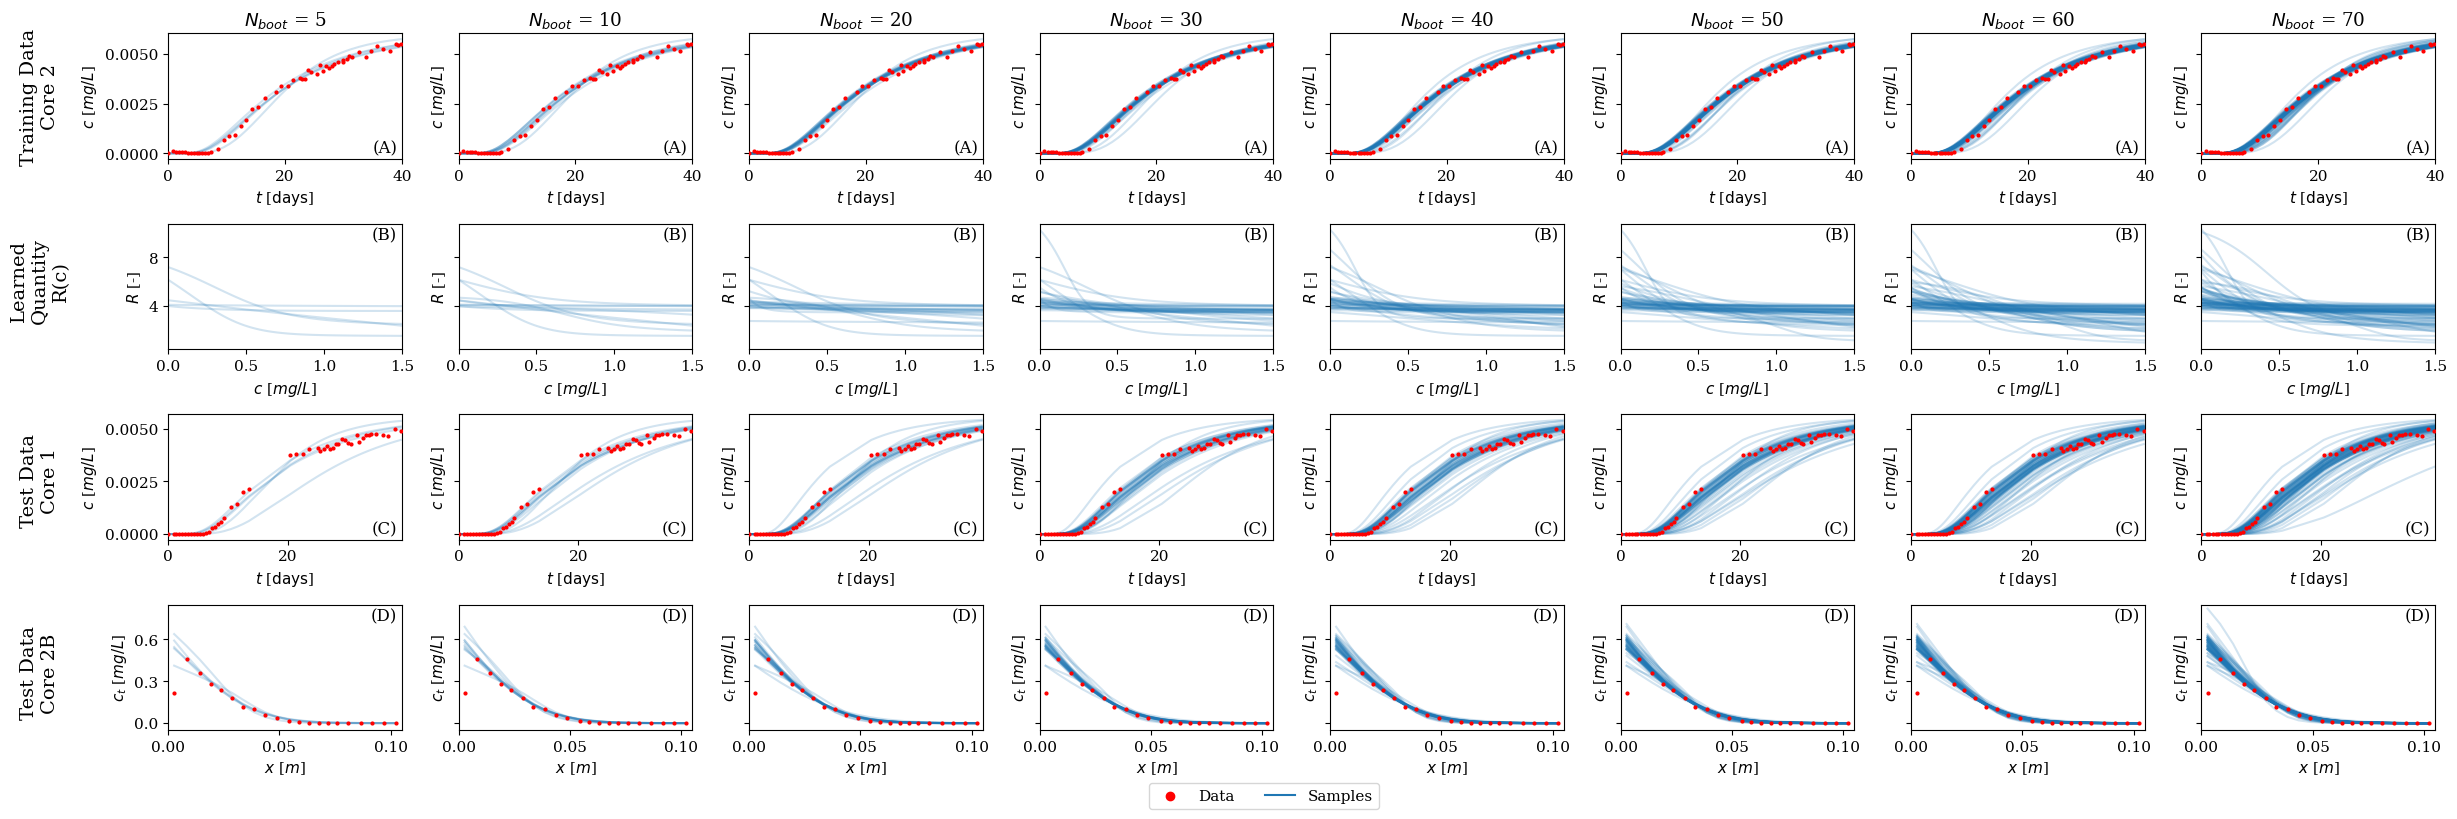

In [ ]:
amount_samples = [5, 10, 20, 30, 40, 50, 60, 70]

nrows = 4
ncols = len(amount_samples)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 2 * nrows), sharey="row")

for i, amount in enumerate(amount_samples):
    plot_core_data(np.array([axs[2, i], axs[0, i], axs[3, i]]))

    axs[2, i].text(0.98, 0.02, "(C)", transform=axs[2, i].transAxes, fontsize=12, va="bottom", ha="right")
    axs[0, i].text(0.98, 0.02, "(A)", transform=axs[0, i].transAxes, fontsize=12, va="bottom", ha="right")
    axs[3, i].text(0.98, 0.98, "(D)", transform=axs[3, i].transAxes, fontsize=12, va="top", ha="right")
    axs[1, i].text(0.98, 0.98, "(B)", transform=axs[1, i].transAxes, fontsize=12, va="top", ha="right")

datasets["ddb"].plot_amount_samples(axs=axs, amount_samples=amount_samples)

fig.text(-0.01, 0.87, "Training Data\nCore 2", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.64, "Learned\nQuantity\nR(c)", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.39, "Test Data\nCore 1", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.15, "Test Data\nCore 2B", rotation=90, va="center", ha="center", fontsize=14)

fig.legend(
    [
        plt.scatter([], [], marker="o", color="r"),
        plt.plot([], [], "C0", "-")[0],
    ],
    ["Data", "Samples"],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.03),
)

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "ddb_amount_samples_large")
plt.show()

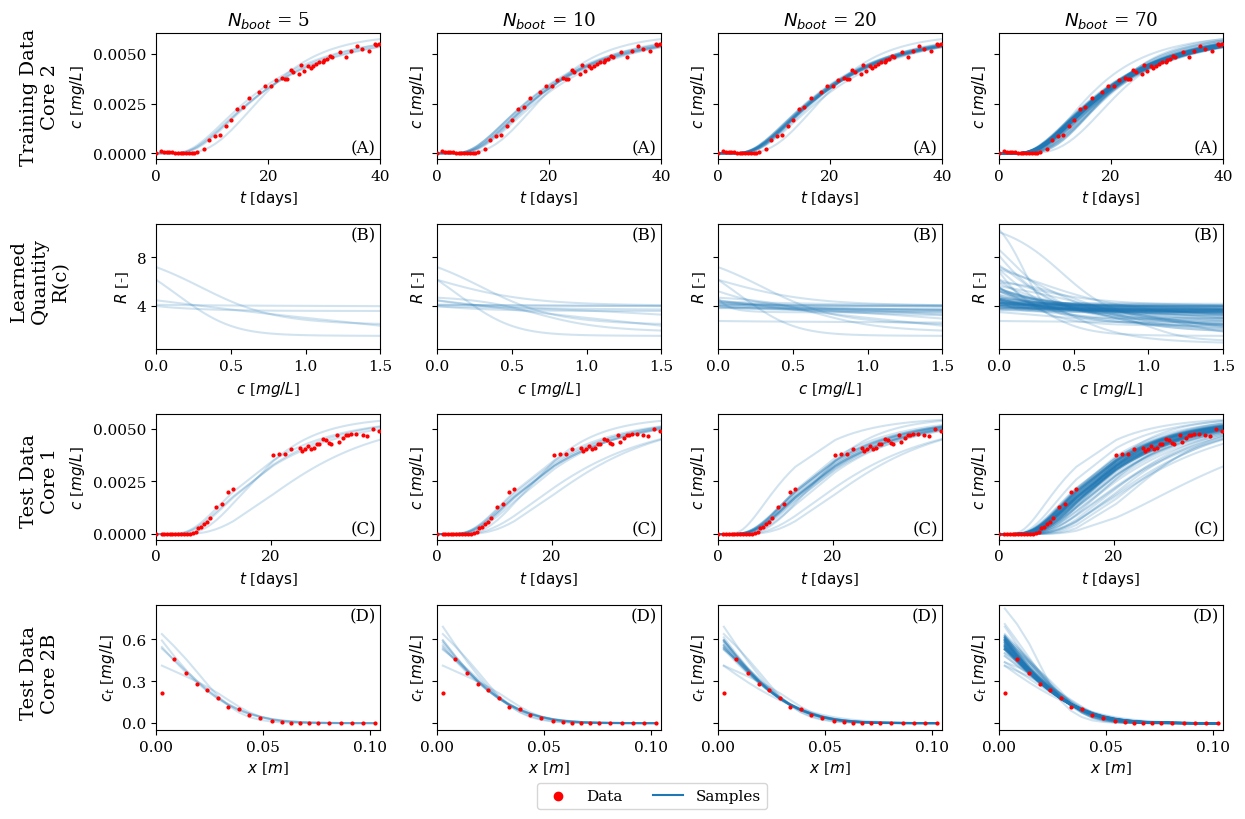

In [ ]:
amount_samples = [5, 10, 20, 70]

nrows = 4
ncols = len(amount_samples)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 2 * nrows), sharey="row")

for i, amount in enumerate(amount_samples):
    plot_core_data(np.array([axs[2, i], axs[0, i], axs[3, i]]))

    axs[2, i].text(0.98, 0.02, "(C)", transform=axs[2, i].transAxes, fontsize=12, va="bottom", ha="right")
    axs[0, i].text(0.98, 0.02, "(A)", transform=axs[0, i].transAxes, fontsize=12, va="bottom", ha="right")
    axs[3, i].text(0.98, 0.98, "(D)", transform=axs[3, i].transAxes, fontsize=12, va="top", ha="right")
    axs[1, i].text(0.98, 0.98, "(B)", transform=axs[1, i].transAxes, fontsize=12, va="top", ha="right")

datasets["ddb"].plot_amount_samples(axs=axs, amount_samples=amount_samples)

fig.text(-0.01, 0.87, "Training Data\nCore 2", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.64, "Learned\nQuantity\nR(c)", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.39, "Test Data\nCore 1", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.15, "Test Data\nCore 2B", rotation=90, va="center", ha="center", fontsize=14)

fig.legend(
    [
        plt.scatter([], [], marker="o", color="r"),
        plt.plot([], [], "C0", "-")[0],
    ],
    ["Data", "Samples"],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.03),
)

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "ddb_amount_samples")
plt.show()

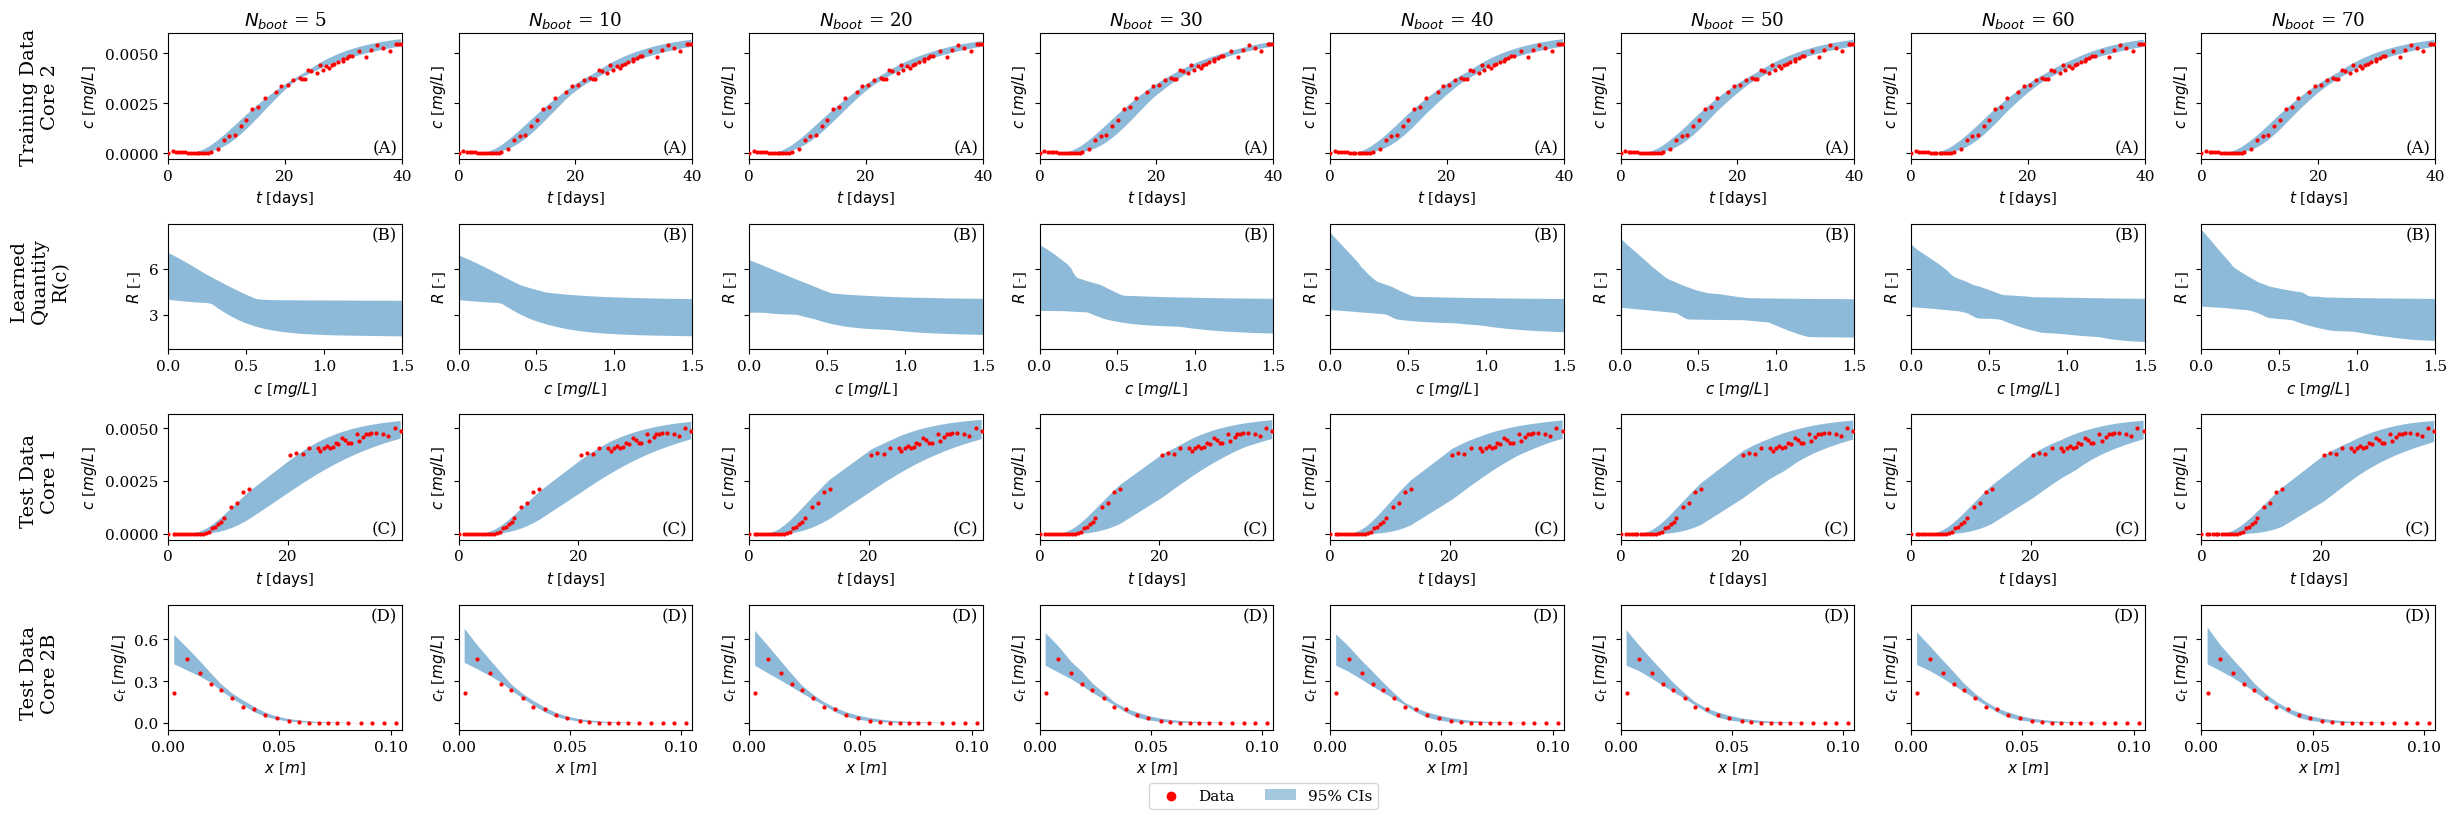

In [ ]:
amount_samples = [5, 10, 20, 30, 40, 50, 60, 70]

nrows = 4
ncols = len(amount_samples)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 2 * nrows), sharey="row")

for i, amount in enumerate(amount_samples):
    plot_core_data(np.array([axs[2, i], axs[0, i], axs[3, i]]))

    axs[2, i].text(0.98, 0.02, "(C)", transform=axs[2, i].transAxes, fontsize=12, va="bottom", ha="right")
    axs[0, i].text(0.98, 0.02, "(A)", transform=axs[0, i].transAxes, fontsize=12, va="bottom", ha="right")
    axs[3, i].text(0.98, 0.98, "(D)", transform=axs[3, i].transAxes, fontsize=12, va="top", ha="right")
    axs[1, i].text(0.98, 0.98, "(B)", transform=axs[1, i].transAxes, fontsize=12, va="top", ha="right")

datasets["ddb"].plot_amount_samples(axs=axs, amount_samples=amount_samples, intervals=0.95)

fig.text(-0.01, 0.87, "Training Data\nCore 2", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.64, "Learned\nQuantity\nR(c)", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.39, "Test Data\nCore 1", rotation=90, va="center", ha="center", fontsize=14)
fig.text(-0.01, 0.15, "Test Data\nCore 2B", rotation=90, va="center", ha="center", fontsize=14)

fig.legend(
    [
        plt.scatter([], [], marker="o", color="r"),
        mpatches.Rectangle((0, 0), 1, 1, fc="C0", alpha=0.4),
    ],
    ["Data", "95% CIs"],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.03),
)

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "ddb_amount_samples_intervals")
plt.show()

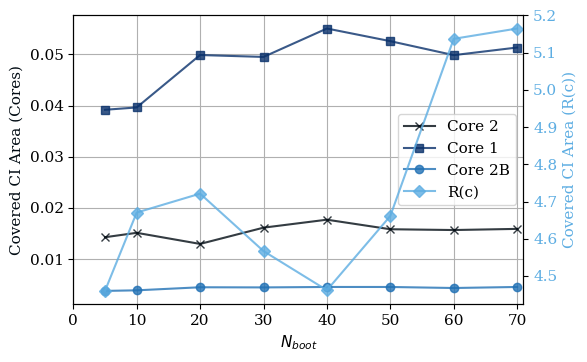

In [ ]:
amount_samples = [5, 10, 20, 30, 40, 50, 60, 70]

fig, axs = datasets["ddb"].interval_areas_amount_samples(amount_samples=amount_samples, intervals=0.95)

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "ddb_amount_samples_interval_areas")
plt.show()

DDB vs MCMC results

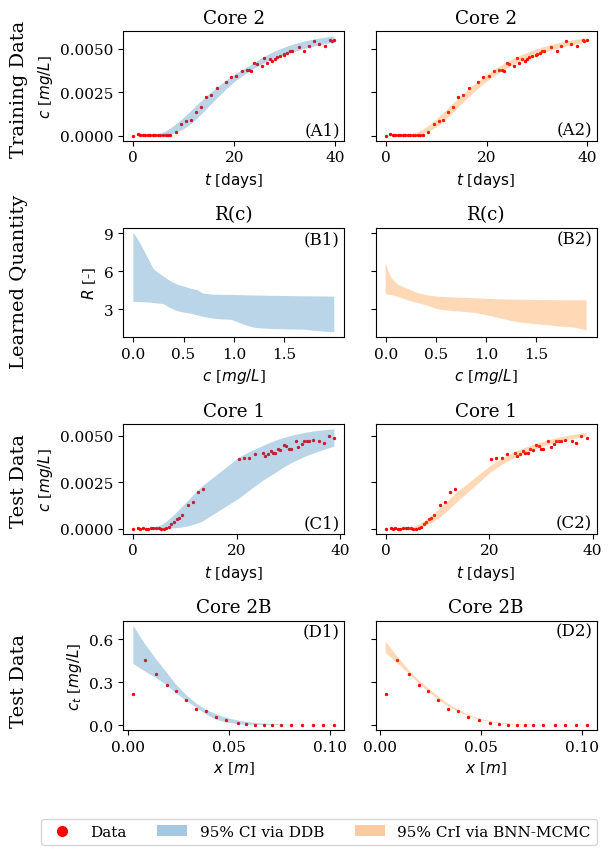

In [ ]:
nrows = 4
ncols = 2
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 2 * nrows), sharey="row")

for row in range(nrows):
    for col in range(ncols):
        dataset = datasets_list[col]
        if row == 0:
            x_data = core2_df["time"]
            x_pred = core2_df["time"]
            y_data = core2_df["c_diss"]
            y_pred = dataset.core2

            x_pred_map = x_data
            y_pred_map = datasets_list[1].core2

        if row == 1:
            x_data = dataset.ret_x
            x_pred = dataset.ret_x
            y_pred = dataset.ret_y
            y_data = dataset.ret_y

            x_pred_map = datasets_list[1].ret_x
            y_pred_map = datasets_list[1].ret_y

        if row == 2:
            x_data = core1_df["time"]
            x_pred = core1_df["time"]
            y_data = core1_df["c_diss"]
            y_pred = dataset.core1

            x_pred_map = core1_df["time"]
            y_pred_map = datasets_list[1].core1

        if row == 3:
            x_data = core2b_df["x"]
            x_pred = core2b_df["x"]
            y_data = core2b_df["c_tot"]
            y_pred = dataset.core2b

            x_pred_map = x_data
            y_pred_map = datasets_list[1].core2b

        ax = axs[row, col]
        if row != 1:  # no data for ret
            ax.scatter(x_data, y_data, s=2, c="r", alpha=1.0)

        ax.fill_between(
            x_pred,
            *np.percentile(y_pred, [2.5, 97.5], axis=0),
            edgecolor="none",
            alpha=0.3,
            facecolor=f"C{col}",
            zorder=1000,
        )

for col in range(ncols):
    axs[0, col].set_title("Core 2")
    axs[1, col].set_title("R(c)")
    axs[2, col].set_title("Core 1")
    axs[3, col].set_title("Core 2B")

axs[0, 0].text(0.98, 0.02, "(A1)", transform=axs[0, 0].transAxes, fontsize=12, va="bottom", ha="right")
axs[0, 1].text(0.98, 0.02, "(A2)", transform=axs[0, 1].transAxes, fontsize=12, va="bottom", ha="right")
axs[1, 0].text(0.98, 0.98, "(B1)", transform=axs[1, 0].transAxes, fontsize=12, va="top", ha="right")
axs[1, 1].text(0.98, 0.98, "(B2)", transform=axs[1, 1].transAxes, fontsize=12, va="top", ha="right")
axs[2, 0].text(0.98, 0.02, "(C1)", transform=axs[2, 0].transAxes, fontsize=12, va="bottom", ha="right")
axs[2, 1].text(0.98, 0.02, "(C2)", transform=axs[2, 1].transAxes, fontsize=12, va="bottom", ha="right")
axs[3, 0].text(0.98, 0.98, "(D1)", transform=axs[3, 0].transAxes, fontsize=12, va="top", ha="right")
axs[3, 1].text(0.98, 0.98, "(D2)", transform=axs[3, 1].transAxes, fontsize=12, va="top", ha="right")

fig.text(0.0, 0.88, "Training Data", rotation=90, va="center", ha="center", fontsize=14)
fig.text(0.0, 0.64, "Learned Quantity", rotation=90, va="center", ha="center", fontsize=14)
fig.text(0.0, 0.39, "Test Data", rotation=90, va="center", ha="center", fontsize=14)
fig.text(0.0, 0.14, "Test Data", rotation=90, va="center", ha="center", fontsize=14)

legend_elements = [
    plt.Line2D([0], [0], marker="o", color="r", label="Data", linestyle="", markersize=7),
    mpatches.Rectangle((0, 0), 1, 1, fc="C0", label="95% CI via DDB", alpha=0.4),
    mpatches.Rectangle((0, 0), 1, 1, fc="C1", label="95% CrI via BNN-MCMC", alpha=0.4),
]

plot_basics.set_retardation_axes_stuff(axs[1, 0], set_xlabel=True, set_ylabel=True)
plot_basics.set_retardation_axes_stuff(axs[1, 1], set_xlabel=True, set_ylabel=False)
for row in range(nrows):
    for col in range(ncols):
        if row == 1:
            continue
        ax = axs[row, col]
        core = {0: "2", 2: "1", 3: "2B"}[row]
        plot_basics.set_concentration_axes_stuff(ax, core=core, set_xlabel=True, set_ylabel=col == 0,)

fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.075))

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "mcmc_vs_ddb")
plt.show()